In [1]:
import cafe

cafe.logger.setLevel("DEBUG")

INFO                                                                                                                                                                                                    
            _____     _ _ ______    _       ______            _                                                                                                                                         
           / ____|   | | |  ____|  | |     |  ____|          | |                                                                                                                                        
          | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __                                                                                                                     
          | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__|                                                                                                                

添加保存原生h5ad文件功能，重新运行（直接运行会全部里程碑均为离散点会报错，适当调参可成功执行），查看整体结果和速率图

In [ ]:
# model_name = "20251110_124249__celldancer-conda__FzXaazX2CG" # 调参后，可以成功构建轨迹，但是特别错乱
model_name = "20251112_194344__celldancer-conda__Et3xKjNgri" # 对齐赋值后，velocity embedding一致，构建轨迹出错, 这是由于大量的0导致的稀疏结果
# model_name = "20251117_192530__celldancer-conda__8iLKN1C0po" # 调整完成
fadata = cafe.data.read_pancrease()
fadata.load_trajectory_dict(model_name_list=[model_name])
fadata

DEBUG    |- Reading data from '/root/PyCode/scRNA/data/Pancreas/endocrinogenesis_day15.h5ad'...                                                                                                         
DEBUG    |- transfer 'X' and 'Spliced' matrix from csr to csc for better dynverse docker performance                                                                                                    
DEBUG    |- Create a FateAnnData object from an existing AnnData object.                                                                                                                                
DEBUG    |- recognizing prior information...                                                                                                                                                            
DEBUG    |--- recognize 'clusters' in '.obs' columns as 'cluster' key                                                                                                                               

AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'raw_index'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'id', 'cfe', 'filename'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'counts'
    obsp: 'distances', 'connectivities'

DEBUG    |- extract 'clusters' from prior infomation as parameter 'color'                                                                                                                               
DEBUG    |- extract 'X_umap' from prior infomation as parameter 'basis'                                                                                                                                 
DEBUG    |- plot_trajectory                                                                                                                                                                             


AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'raw_index'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'id', 'cfe', 'filename'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'counts'
    obsp: 'distances', 'connectivities'

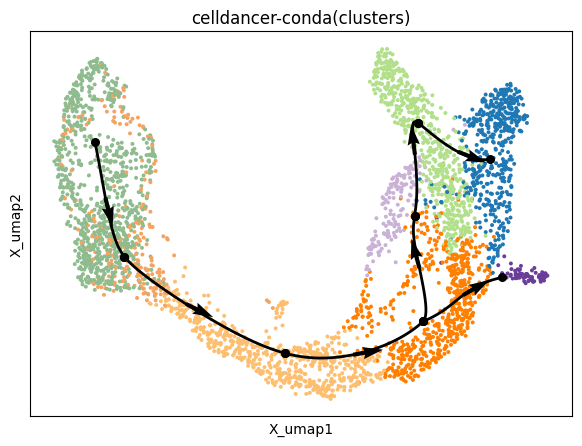

In [5]:
cafe.plot.plot_trajectory(fadata, model_name=model_name)
# cafe.plot.plot_wrapper(fadata, model_name=model_name, wrapper_type="velocity")
fadata

回头看看CellDancerd的原生h5ad文件, 这里的h5ad属于新版生成的中间结果，与上述的pkl文件不对应

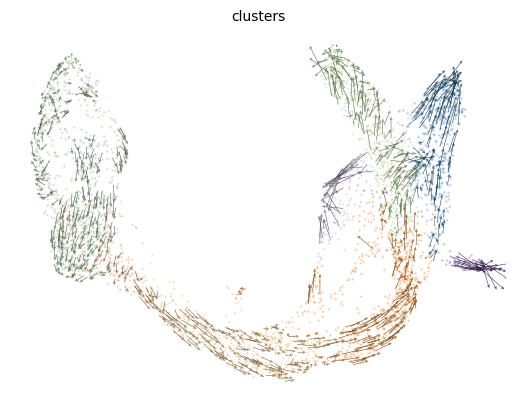

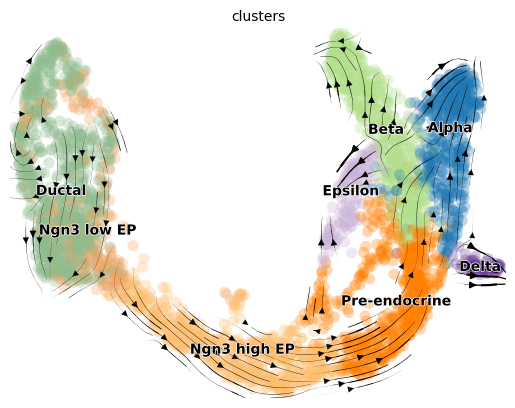

AnnData object with n_obs × n_vars = 3696 × 2000
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'raw_index', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts'
    var: 'highly_variable_genes', 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'highly_variable'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'filename', 'id', 'neighbors', 'pca'
    obsm: 'X_pca', 'X_umap', 'velocity_umap'
    layers: 'Ms', 'Mu', 'counts', 'expression', 'spliced', 'unspliced'
    obsp: 'connectivities', 'distances'

In [4]:
import scanpy as sc
import scvelo as scv

adata = sc.read(f".cfe/pancreas/h5ad/{model_name}.h5ad")
scv.pl.velocity_embedding(adata)
scv.pl.velocity_embedding_stream(adata)
adata.obsm["velocity_umap"]  # 还是会有大量的0
adata

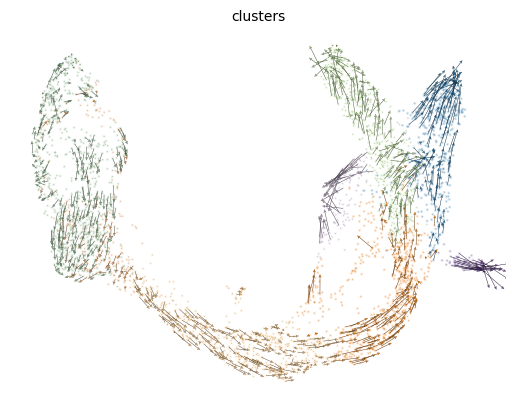

In [5]:
import numpy as np

# 还是会有大量的0
# b
np.savetxt("velocity_umap_celldancer_cafe.txt", adata.obsm["velocity_umap"])
# 读取CellDancer的直接运行结果
adata.obsm["velocity_raw_umap"] = np.loadtxt("/root/PyCode/scRNA/CellFateExplorer/notebook/velocity_umap_celldancer_raw.txt")
scv.pl.velocity_embedding(adata, vkey="velocity_raw")

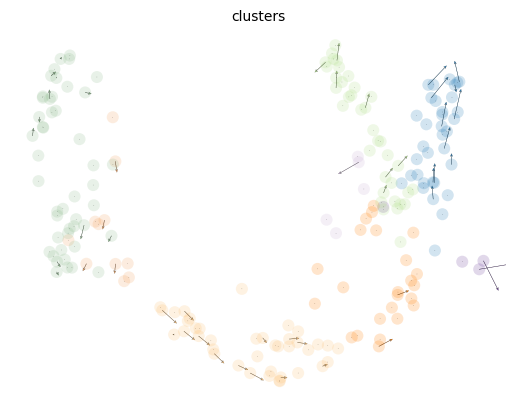

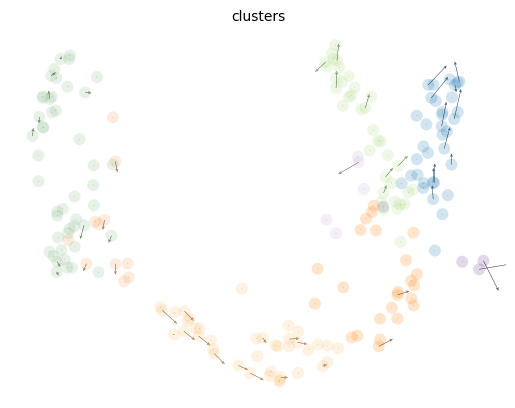

In [6]:
# 前100的细胞完全一致，前200的细胞出问题了
first_n = 200
scv.pl.velocity_embedding(adata[:first_n], vkey="velocity_raw")
scv.pl.velocity_embedding(adata[:first_n], vkey="velocity")

###  使用CellDancer原生可视化该结果(celldancer conda环境)， 可视化效果还是可以的，与原生CellDancer直接运行结果近似。应该是PAGA计算的时候的置信度过低导致大量离散的里程碑

In [7]:
# import numpy as np
# import matplotlib.pyplot as plt
# import celldancer as cd

# cellDancer_df = cd.utilities.adata_to_df_with_embed(
#     adata,
#     us_para=["Mu", "Ms"],
#     cell_type_para="clusters",
#     embed_para="X_umap",
# )

# cellDancer_df[["velocity1", "velocity2"]] = np.stack(np.expand_dims(adata.obsm["velocity_umap"],0).repeat(adata.shape[1],axis=0)).reshape(-1, 2)

# fig, ax = plt.subplots(figsize=(10, 10))
# im = cd.cdplt.scatter_cell(
#     ax,
#     cellDancer_df,
#     colors=cd.cdplt.colormap.colormap_pancreas,
#     alpha=0.5,
#     s=10,
#     velocity=True,
#     legend="on",
#     min_mass=5,
#     arrow_grid=(20, 20)
# )
# ax.axis("off")
# plt.show()

重新提取数据并添加轨迹

In [8]:
from cafe.method.function.cf_celldancer  import extract_trajectory_dict

# 又可以从h5ad文件添加轨迹
adata = adata[~((adata.obsm["velocity_umap"]  == 0).all(axis=1))] #  避免全局稀疏速率，只保留有速率的部分
fadata.add_model_name("celldancer-conda-rewrite")
trajectory_dict = extract_trajectory_dict(adata)
trajectory_dict

{'wrapper_type': 'velocity',
 'velocity': None,
 'velocity_graph': None,
 'velocity_graph_neg': None,
 'velocity_embedding': ArrayView([[-0.18302982, -0.47696981],
            [ 0.20678609,  0.0588777 ],
            [ 0.73215211, -1.04212488],
            ...,
            [ 0.11360749,  0.19489243],
            [ 0.29582567, -0.43113808],
            [ 0.40198131,  0.3854935 ]]),
 'neighbors': {'distances': <845x845 sparse matrix of type '<class 'numpy.float64'>'
  	with 5720 stored elements in Compressed Sparse Row format>,
  'connectivities': <845x845 sparse matrix of type '<class 'numpy.float32'>'
  	with 8036 stored elements in Compressed Sparse Row format>},
 'obs_index': Index(['cell_001', 'cell_004', 'cell_010', 'cell_012', 'cell_015', 'cell_020',
        'cell_025', 'cell_029', 'cell_030', 'cell_031',
        ...
        'cell_3656', 'cell_3657', 'cell_3658', 'cell_3665', 'cell_3666',
        'cell_3669', 'cell_3678', 'cell_3685', 'cell_3688', 'cell_3689'],
       dtype='object

In [9]:
# # 使用scVelo可视化
# import scvelo as scv

# basis = "X_umap"
# new_adata = sc.AnnData(X=adata.obsm[basis], obs=adata.obs, obsm=adata.obsm, obsp=adata.obsp, uns=adata.uns)
# new_adata.layers["spliced"] = adata.obsm[basis]
# new_adata.layers["unspliced"] = adata.obsm[basis]
# new_adata.layers["velocity"] = adata.obsm["velocity_umap"]
# new_adata.obsm[basis] = adata.obsm[basis]
# new_adata.obsm["velocity_umap"] = adata.obsm["velocity_umap"]
# scv.pl.velocity_embedding(new_adata)

DEBUG    |- Add trajectory by wrapper type: velocity                                                                                                                                                    
DEBUG    |- Create a FateAnnData object from an existing AnnData object.                                                                                                                                


DEBUG    |- recognizing prior information...                                                                                                                                                            
DEBUG    |--- recognize 'clusters' in '.obs' columns as 'cluster' key                                                                                                                                   
DEBUG    |--- recognize 'X_umap' in '.obsm' keys as 'basis' key                                                                                                                                         
DEBUG    |- filterd adata: AnnData object with n_obs × n_vars = 845 × 2000                                                                                                                              
             obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'raw_index'                                                                                                                

<Axes: title={'center': 'celldancer-conda-rewrite(clusters)'}, xlabel='X_umap1', ylabel='X_umap2'>

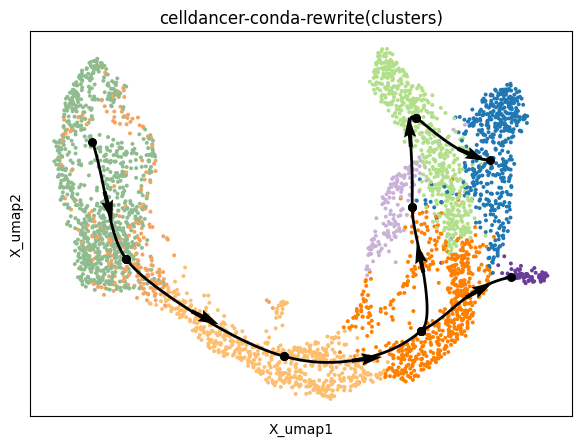

In [13]:
import os
os.environ["TQDM_DISABLE"] = "1"      # 大多数基于 tqdm 的进度条会被禁用
os.environ["NO_COLOR"] = "1"          # 禁色彩，避免富文本输出干扰

# 有时候报错是因为全是离散的里程碑
fadata.add_trajectory_by_type(trajectory_dict)
cafe.plot.plot_trajectory(fadata)

In [11]:
mw = fadata.get_milestone_wrapper()
mw.progressions

,cell_id,from,to,percentage
0,cell_001,Ductal,Ngn3 low EP,0.90
1,cell_015,Ductal,Ngn3 low EP,1.00
2,cell_030,Ductal,Ngn3 low EP,0.00
3,cell_031,Ductal,Ngn3 low EP,1.00
4,cell_036,Ductal,Ngn3 low EP,0.00
...,...,...,...,...
28,cell_3294,Epsilon,Beta,0.53
29,cell_3464,Epsilon,Beta,0.46
30,cell_3488,Pre-endocrine,Epsilon,0.83
31,cell_3554,Epsilon,Beta,0.50


In [12]:
# fadata.add_trajectory_velocity(
#         velocity=trajectory_dict["velocity"],
#         velocity_graph=trajectory_dict.get("velocity_graph"),
#         velocity_graph_neg=trajectory_dict.get("velocity_graph_neg"),
#         velocity_embedding=trajectory_dict.get("velocity_embedding"),
#         neighbors=trajectory_dict.get("neighbors"),
#         obs_index=trajectory_dict.get("obs_index"),
#         var_index=trajectory_dict.get("var_index"),
#         X=trajectory_dict.get("X"),  # add X for velocity method like veloae
#     )